# Exploratory Data Analysis (EDA)

Questo notebook contiene l'analisi preliminare del dataset **PetFinder Adoption Prediction**.

Obiettivi:
- comprendere la struttura del dataset;
- selezionare solo i cani, coerentemente con l'obiettivo del progetto;
- analizzare la distribuzione della variabile target `AdoptionSpeed`;
- creare nuove feature utili per i modelli di Machine Learning;
- salvare il dataset pulito in `data/processed/dogs_clean.csv`.


## 1. Import delle librerie e caricamento del dataset

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/train.csv")

print("Dimensioni dataset originale:", df.shape)
df.head()

Dimensioni dataset originale: (14993, 24)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


## 2. Analisi preliminare del dataset

In questa sezione vengono osservati:
- il tipo delle colonne;
- la presenza di valori mancanti;
- le statistiche descrittive delle variabili numeriche.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  str    
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  RescuerID      14

In [4]:
df.isnull().sum()

Type                0
Name             1265
Age                 0
Breed1              0
Breed2              0
Gender              0
Color1              0
Color2              0
Color3              0
MaturitySize        0
FurLength           0
Vaccinated          0
Dewormed            0
Sterilized          0
Health              0
Quantity            0
Fee                 0
State               0
RescuerID           0
VideoAmt            0
Description        13
PetID               0
PhotoAmt            0
AdoptionSpeed       0
dtype: int64

In [5]:
df.describe()

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,1.457614,10.452078,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,1.467485,1.731208,1.558727,1.914227,1.036617,1.576069,21.259988,41346.028347,0.056760,3.889215,2.516441
std,0.498217,18.155790,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,0.599070,0.667649,0.695817,0.566172,0.199535,1.472477,78.414548,32.444153,0.346185,3.487810,1.177265
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000
50%,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000
75%,2.000000,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000
max,2.000000,255.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,20.000000,3000.000000,41415.000000,8.000000,30.000000,4.000000


## 3. Selezione dei soli cani

Il dataset contiene sia cani sia gatti. Poiché il progetto riguarda il supporto all'adozione dei cani, vengono mantenuti solo i record con `Type = 1`.


In [6]:
dogs = df[df["Type"] == 1].copy()

print("Numero cani:", dogs.shape[0])
print("Numero colonne:", dogs.shape[1])

Numero cani: 8132
Numero colonne: 24


## 4. Distribuzione della variabile target

La variabile da prevedere è `AdoptionSpeed`, che rappresenta la velocità di adozione dell'animale.
Valori più bassi indicano un'adozione più rapida, mentre valori più alti indicano un'adozione più lenta.


In [7]:
adoption_distribution = dogs["AdoptionSpeed"].value_counts().sort_index()
adoption_distribution

AdoptionSpeed
0     170
1    1435
2    2164
3    1949
4    2414
Name: count, dtype: int64

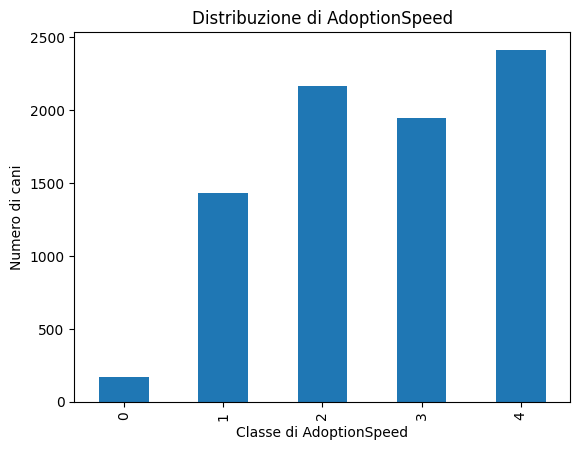

In [8]:
adoption_distribution.plot(kind="bar")

plt.title("Distribuzione di AdoptionSpeed")
plt.xlabel("Classe di AdoptionSpeed")
plt.ylabel("Numero di cani")
plt.show()

## 5. Feature engineering

Vengono create nuove feature derivate per rendere il dataset più informativo e più interpretabile.


### 5.1 Feature derivate dalla descrizione testuale

- `description_len`: lunghezza della descrizione;
- `has_description`: presenza o assenza della descrizione.


In [9]:
dogs["description_len"] = dogs["Description"].fillna("").apply(len)
dogs["has_description"] = dogs["Description"].notna().astype(int)

dogs[["Description", "description_len", "has_description"]].head()

,Description,description_len,has_description
2,Their pregnant mother was dumped by her irresp...,393,1
3,"Good guard dog, very alert, active, obedience ...",146,1
4,This handsome yet cute boy is up for adoption....,390,1
7,Siu Pak just give birth on 13/6/10 to 6puppies...,109,1
10,"For serious adopter, please do sms or call for...",68,1


### 5.2 Fasce di età

La variabile numerica `Age` viene trasformata in una variabile categoriale più interpretabile:

- `puppy`: meno di 8 mesi;
- `young`: da 8 a 23 mesi;
- `adult`: da 24 a 83 mesi;
- `senior`: da 84 mesi in poi.


In [10]:
def age_group(age):
    if age < 8:
        return "puppy"
    elif age < 24:
        return "young"
    elif age < 84:
        return "adult"
    else:
        return "senior"

dogs["age_group"] = dogs["Age"].apply(age_group)

dogs["age_group"].value_counts()

age_group
puppy     5354
adult     1418
young     1157
senior     203
Name: count, dtype: int64

### 5.3 Etichette leggibili per variabili categoriali

Vengono create versioni testuali di alcune variabili codificate numericamente:

- `gender_label`;
- `fur_length_label`;
- `maturity_size_label`.


In [11]:
gender_map = {
    1: "male",
    2: "female",
    3: "mixed"
}

fur_map = {
    1: "short",
    2: "medium",
    3: "long"
}

size_map = {
    1: "small",
    2: "medium",
    3: "large",
    4: "extra_large"
}

dogs["gender_label"] = dogs["Gender"].map(gender_map)
dogs["fur_length_label"] = dogs["FurLength"].map(fur_map)
dogs["maturity_size_label"] = dogs["MaturitySize"].map(size_map)

dogs[
    [
        "Gender",
        "gender_label",
        "FurLength",
        "fur_length_label",
        "MaturitySize",
        "maturity_size_label"
    ]
].head()

,Gender,gender_label,FurLength,fur_length_label,MaturitySize,maturity_size_label
2,1,male,2,medium,2,medium
3,2,female,1,short,2,medium
4,1,male,1,short,2,medium
7,2,female,1,short,2,medium
10,1,male,1,short,2,medium


### 5.4 Razze dei cani

Nel dataset le razze non sono rappresentate direttamente come testo, ma tramite codici numerici nelle colonne:

- `Breed1`: razza principale;
- `Breed2`: seconda razza, se presente;
- `0`: nessuna seconda razza.

Per rendere queste informazioni utilizzabili nel sistema di matching cane–famiglia, viene caricato il file `breed_labels.csv`, che associa ogni codice al nome della razza.

Da questo mapping vengono create due nuove colonne:

- `breed1_label`;
- `breed2_label`.

Queste colonne saranno usate nei notebook successivi per confrontare le razze preferite dalla famiglia con le razze del cane.


In [12]:
breed_labels = pd.read_csv("../data/raw/breed_labels.csv")

breed_map = dict(
    zip(
        breed_labels["BreedID"],
        breed_labels["BreedName"]
    )
)

dogs["breed1_label"] = dogs["Breed1"].map(breed_map)
dogs["breed2_label"] = dogs["Breed2"].map(breed_map)

dogs["breed2_label"] = dogs["breed2_label"].fillna("None")

dogs[[
    "Breed1",
    "breed1_label",
    "Breed2",
    "breed2_label"
]].head()

,Breed1,breed1_label,Breed2,breed2_label
2,307,Mixed Breed,0,None
3,307,Mixed Breed,0,None
4,307,Mixed Breed,0,None
7,307,Mixed Breed,0,None
10,307,Mixed Breed,0,None


## 6. Analisi delle feature create

In questa sezione vengono confrontate alcune feature con la media di `AdoptionSpeed`.
Un valore medio più basso indica, in media, un'adozione più rapida.


### 6.1 Fascia d'età e velocità di adozione

In [13]:
dogs.groupby("age_group")["AdoptionSpeed"].mean().sort_values()

age_group
puppy     2.518678
adult     2.746121
senior    2.778325
young     2.872083
Name: AdoptionSpeed, dtype: float64

### 6.2 Genere e velocità di adozione

In [14]:
dogs.groupby("gender_label")["AdoptionSpeed"].mean().sort_values()

gender_label
male      2.488186
female    2.677093
mixed     2.749714
Name: AdoptionSpeed, dtype: float64

### 6.3 Taglia e velocità di adozione

In [15]:
dogs.groupby("maturity_size_label")["AdoptionSpeed"].mean().sort_values()

maturity_size_label
extra_large    2.000000
small          2.434996
large          2.514474
medium         2.665742
Name: AdoptionSpeed, dtype: float64

In [16]:
dogs["maturity_size_label"].value_counts()

maturity_size_label
medium         6127
small          1223
large           760
extra_large      22
Name: count, dtype: int64

### 6.4 Presenza della descrizione e velocità di adozione

In [17]:
dogs.groupby("has_description")["AdoptionSpeed"].mean()

has_description
0    2.750000
1    2.615034
Name: AdoptionSpeed, dtype: float64

### 6.5 Numero di fotografie e AdoptionSpeed

In [18]:
dogs[["PhotoAmt", "AdoptionSpeed"]].corr(numeric_only=True)

,PhotoAmt,AdoptionSpeed
PhotoAmt,1.000000,-0.002064
AdoptionSpeed,-0.002064,1.000000


### 6.6 Razze principali

In questa sezione viene osservata la distribuzione delle razze principali.  
Questa analisi è utile perché alcune razze sono molto frequenti, mentre molte altre compaiono poche volte. Per questo motivo la razza non viene usata come feature principale nei modelli predittivi, ma viene utilizzata nel sistema di matching come preferenza espressa dalla famiglia.


In [19]:
dogs["breed1_label"].value_counts().head(20)

breed1_label
Mixed Breed                  5923
Labrador Retriever            205
Shih Tzu                      189
Poodle                        167
Terrier                       161
Golden Retriever              151
German Shepherd Dog            98
Beagle                         90
Spitz                          89
Rottweiler                     88
Schnauzer                      69
Miniature Pinscher             67
Jack Russell Terrier           64
Doberman Pinscher              62
Cocker Spaniel                 41
Dalmatian                      39
Husky                          37
Chihuahua                      37
Dachshund                      28
Belgian Shepherd Malinois      26
Name: count, dtype: int64

## 7. Salvataggio del dataset pulito

Il dataset finale, contenente solo i cani e le nuove feature create, viene salvato nella cartella `data/processed`.
Questo file sarà utilizzato nei notebook successivi per l'addestramento dei modelli.


In [20]:
os.makedirs("../data/processed", exist_ok=True)

dogs.to_csv("../data/processed/dogs_clean.csv", index=False)

print("Dataset pulito salvato in ../data/processed/dogs_clean.csv")
print("Dimensioni dataset pulito:", dogs.shape)

Dataset pulito salvato in ../data/processed/dogs_clean.csv
Dimensioni dataset pulito: (8132, 32)


## 8. Conclusioni dell'EDA

L'analisi esplorativa mostra che il dataset contiene un numero significativo di cani e che la variabile target `AdoptionSpeed` è sbilanciata tra le diverse classi.

Sono state create nuove feature utili per le fasi successive del progetto:

- `description_len`;
- `has_description`;
- `age_group`;
- `gender_label`;
- `fur_length_label`;
- `maturity_size_label`;
- `breed1_label`;
- `breed2_label`.

Le feature derivate rendono il dataset più interpretabile e permettono di costruire sia modelli predittivi sia un sistema di matching cane–famiglia.

In particolare, le nuove colonne relative alle razze saranno utilizzate nel sistema di raccomandazione per confrontare le razze preferite dagli adottanti con la razza principale e secondaria dei cani presenti nel dataset.
